**A STATISTICAL RESEARCH ON THE EFFECTS OF MENTAL HEALTH ON STUDENTS’ CGPA******

In [4]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import seaborn as sns
import datetime
import random
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Reading the Dataset

In [7]:
!pip install -q kagglehub

import kagglehub
import pandas as pd
import os

# Download the Student Mental Health dataset directly from Kaggle
path = kagglehub.dataset_download("shariful07/student-mental-health")

print("Dataset downloaded to:", path)
print("Files:", os.listdir(path))

100%|██████████| 1.62k/1.62k [00:00<00:00, 1.22MB/s]

Extracting files...
Dataset downloaded to: /root/.cache/kagglehub/datasets/shariful07/student-mental-health/versions/3
Files: ['Student Mental health.csv']


In [37]:
csv_path = os.path.join(path, "Student Mental health.csv")

df = pd.read_csv(csv_path)

print("Dataset loaded successfully!")
print(df.shape)

df.head()

Dataset loaded successfully!
(101, 11)


,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


In [9]:
df.dtypes

,0
Timestamp,object
Choose your gender,object
Age,float64
What is your course?,object
Your current year of Study,object
What is your CGPA?,object
Marital status,object
Do you have Depression?,object
Do you have Anxiety?,object
Do you have Panic attack?,object


In [10]:
df.nunique()

,0
Timestamp,92
Choose your gender,2
Age,7
What is your course?,49
Your current year of Study,7
What is your CGPA?,6
Marital status,2
Do you have Depression?,2
Do you have Anxiety?,2
Do you have Panic attack?,2


In [11]:
df.isnull().sum()

,0
Timestamp,0
Choose your gender,0
Age,1
What is your course?,0
Your current year of Study,0
What is your CGPA?,0
Marital status,0
Do you have Depression?,0
Do you have Anxiety?,0
Do you have Panic attack?,0


In [12]:
df = df.dropna(how='any',axis=0)

In [13]:
df.isnull().sum()

,0
Timestamp,0
Choose your gender,0
Age,0
What is your course?,0
Your current year of Study,0
What is your CGPA?,0
Marital status,0
Do you have Depression?,0
Do you have Anxiety?,0
Do you have Panic attack?,0


# Data Visualization

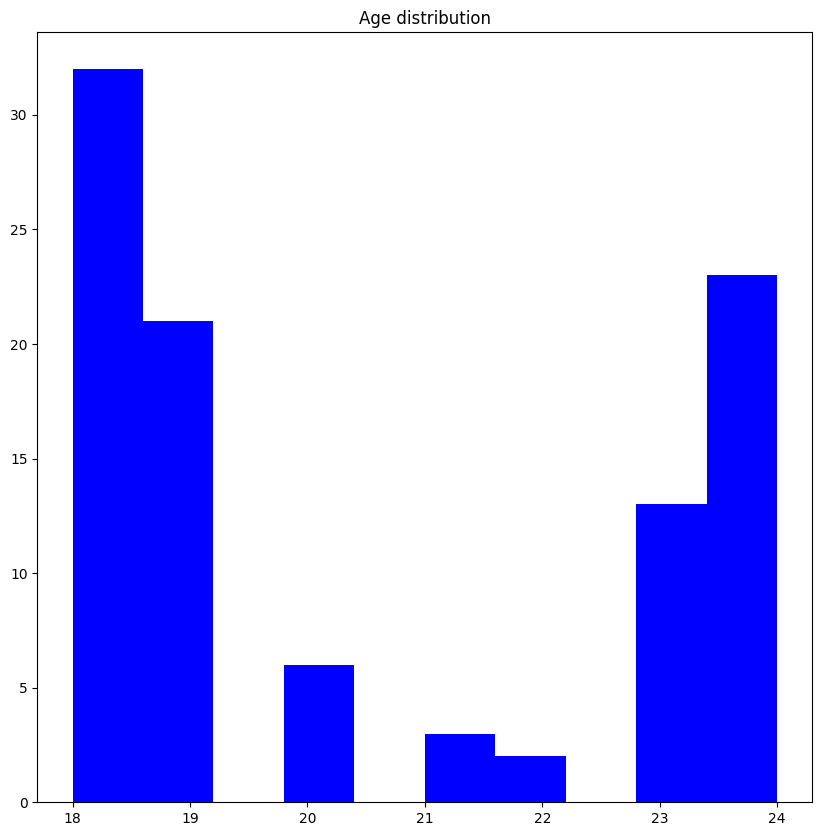

In [14]:
plt.figure(figsize=(10,10))
plt.hist(df['Age'],color='b')
plt.title("Age distribution");

In [15]:
df.rename(columns = {'Choose your gender': 'gender'}, inplace = True)

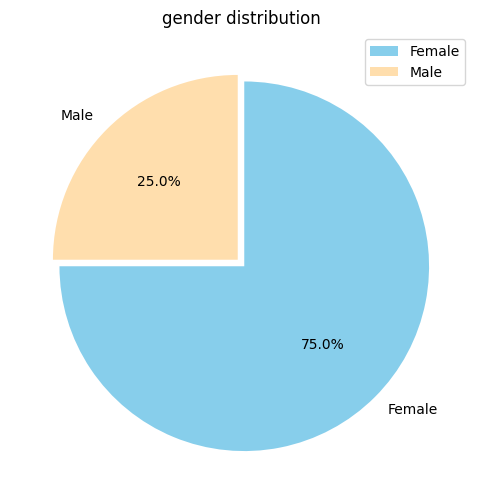

In [16]:
plt.figure(figsize=(12,6))
plt.title("gender distribution")
g = plt.pie(df.gender.value_counts(), explode=(0.025,0.025), labels=df.gender.value_counts().index, colors=['skyblue','navajowhite'],autopct='%1.1f%%', startangle=180);
plt.legend()
plt.show()

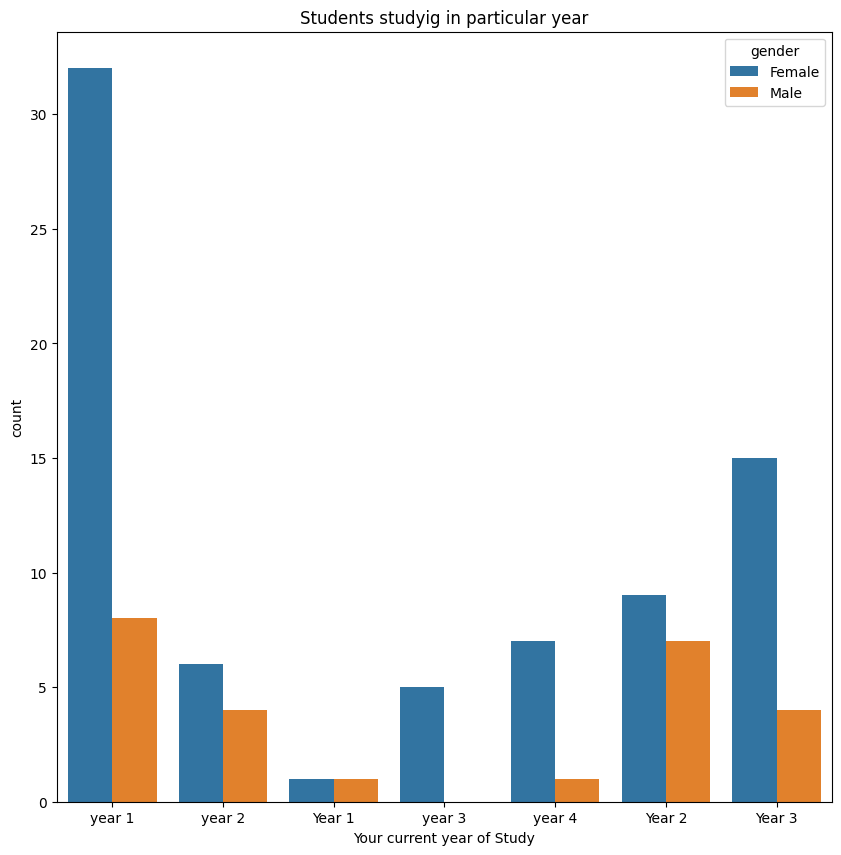

In [20]:
plt.figure(figsize=(10,10))
sns.countplot(x='Your current year of Study', hue='gender', data=df)
plt.title("Students studyig in particular year");

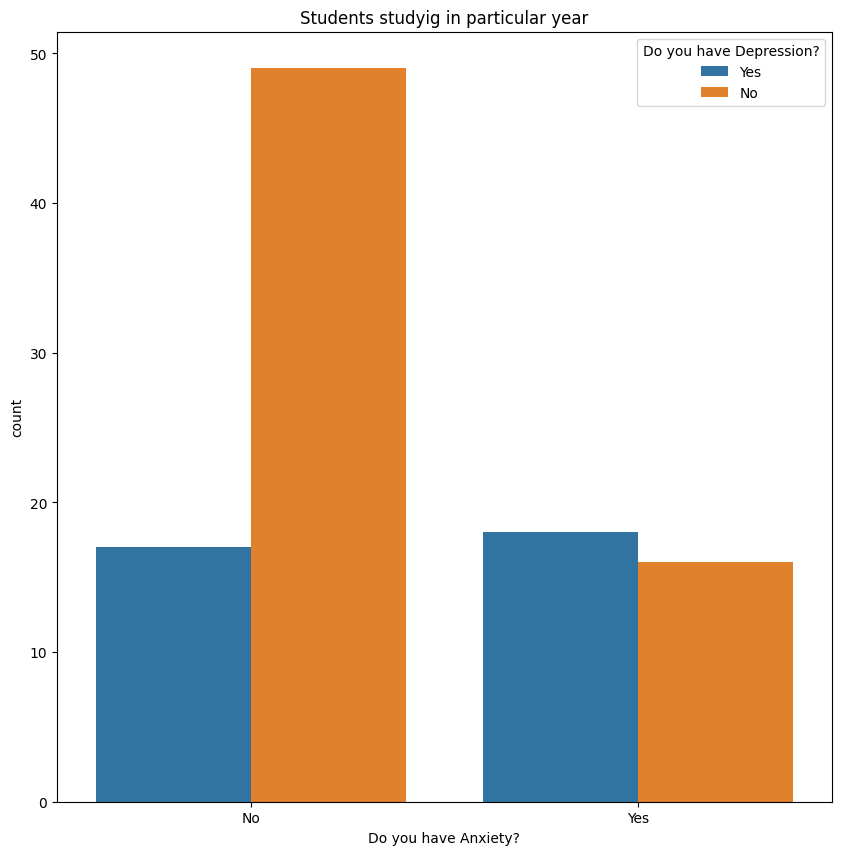

In [22]:
plt.figure(figsize=(10,10))
sns.countplot(x='Do you have Anxiety?', hue='Do you have Depression?', data=df)
plt.title("Students studyig in particular year");
plt.show()

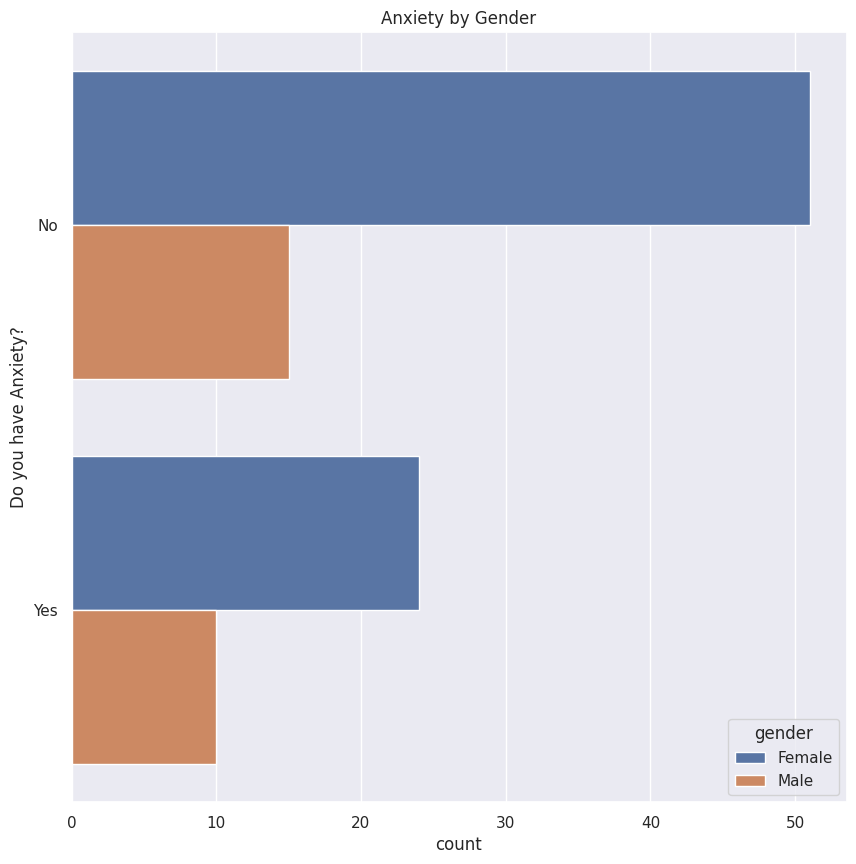

In [23]:
plt.figure(figsize=(10,10))
sns.set_theme(style="darkgrid")
ax = sns.countplot(y="Do you have Anxiety?", hue="gender", data=df)
plt.title("Anxiety by Gender")
plt.show()

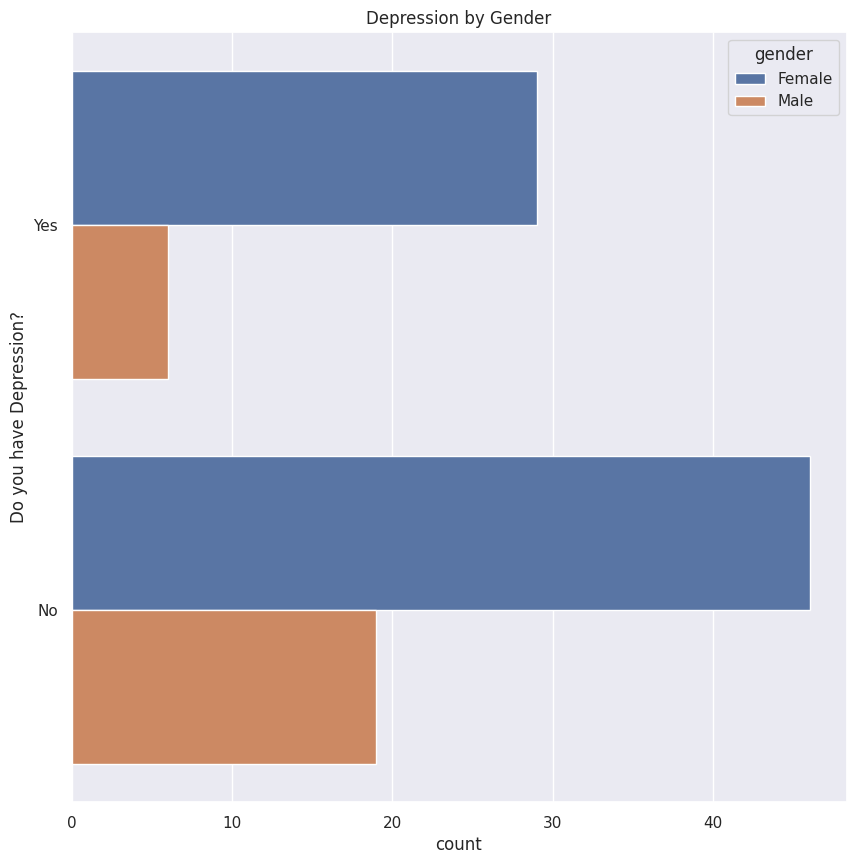

In [24]:
plt.figure(figsize=(10,10))
sns.set_theme(style="darkgrid")
ax = sns.countplot(y="Do you have Depression?", hue="gender", data=df)
plt.title("Depression by Gender")
plt.show()

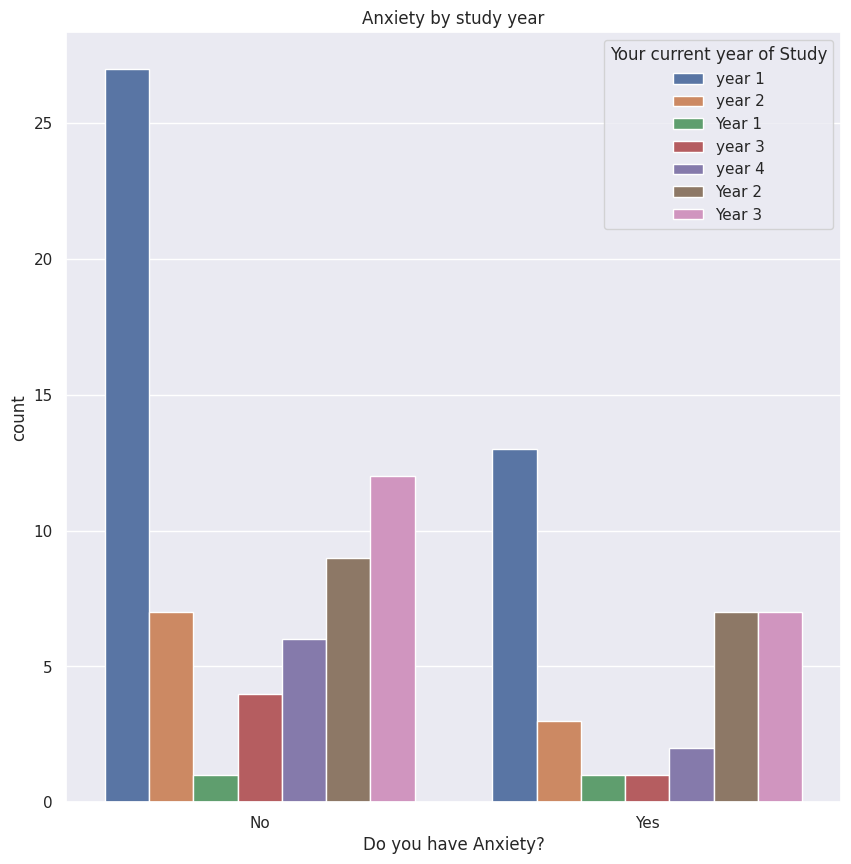

In [25]:
plt.figure(figsize=(10,10))
sns.set_theme(style="darkgrid")
ax = sns.countplot(x="Do you have Anxiety?", hue="Your current year of Study", data=df)
plt.title("Anxiety by study year")
plt.show()

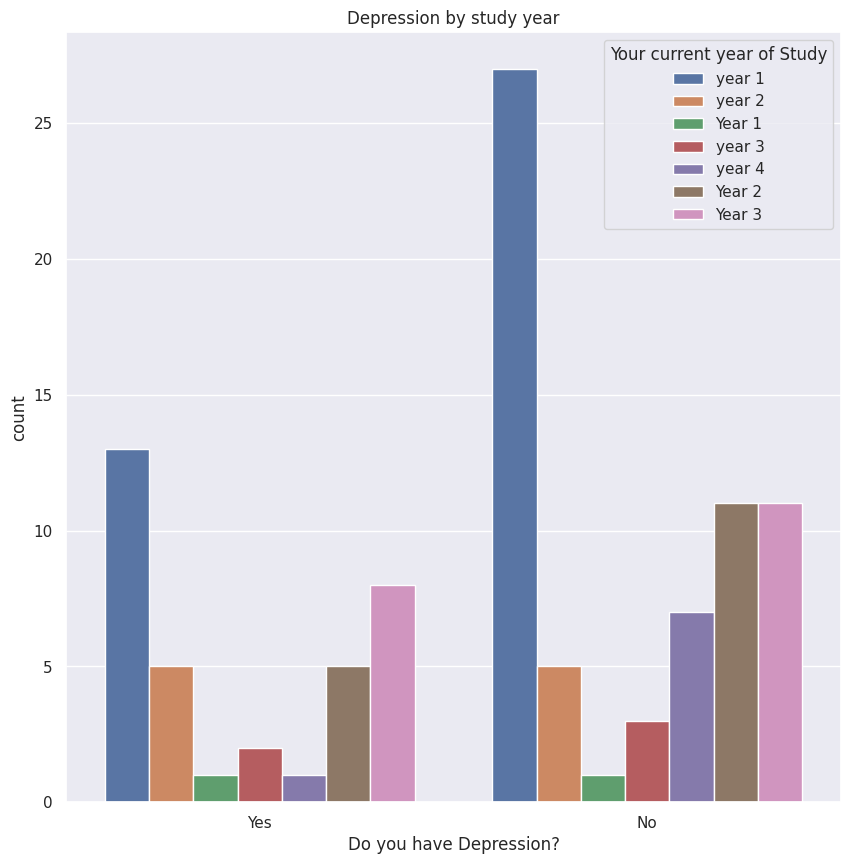

In [26]:
plt.figure(figsize=(10,10))
sns.set_theme(style="darkgrid")
ax = sns.countplot(x="Do you have Depression?", hue="Your current year of Study", data=df)
plt.title("Depression by study year")
plt.show()

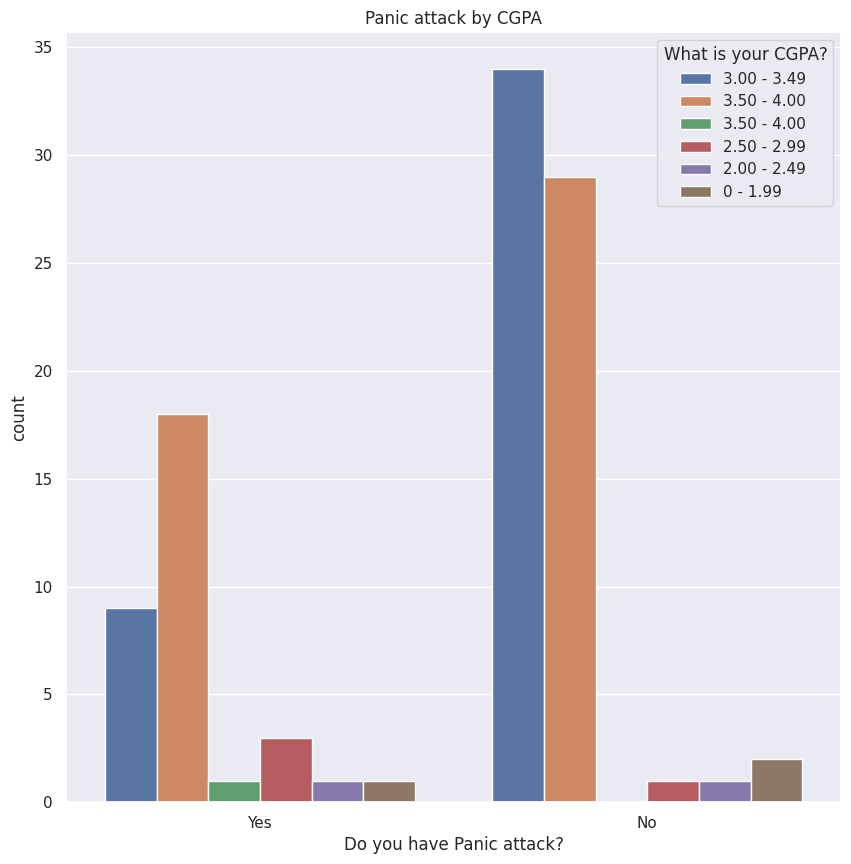

In [27]:
plt.figure(figsize=(10,10))
sns.set_theme(style="darkgrid")
ax = sns.countplot(x="Do you have Panic attack?", hue="What is your CGPA?", data=df)
plt.title("Panic attack by CGPA")
plt.show()

**upvote if you like it and Please check out my other codes :)**

## Hugging Face Sentiment Analysis

This section performs sentiment analysis using the Hugging Face Inference API.

**Important:** The original student mental health dataset mainly contains structured survey responses rather than free-text comments. Therefore, the code below converts each student's mental-health responses into a short text summary and then classifies that text using a Hugging Face sentiment model.


In [28]:
!pip install -q huggingface_hub

### Add your Hugging Face API token

Create a Hugging Face access token from your Hugging Face account and paste it below.

**Do not share your real API token publicly.**


In [39]:
import os
from getpass import getpass

# Securely enter the token when the notebook runs
os.environ["HF_TOKEN"] = getpass("Enter your Hugging Face token: ")

Enter your Hugging Face token: ··········


### Create text from student mental-health responses

The dataset does not contain a natural free-text review/comment field, so we create a short textual representation using the Depression, Anxiety, Panic Attack, and Specialist Treatment columns.


In [40]:
def create_student_text(row):
    depression = (
        "I experience depression."
        if row["Do you have Depression?"] == "Yes"
        else "I do not experience depression."
    )

    anxiety = (
        "I experience anxiety."
        if row["Do you have Anxiety?"] == "Yes"
        else "I do not experience anxiety."
    )

    panic = (
        "I experience panic attacks."
        if row["Do you have Panic attack?"] == "Yes"
        else "I do not experience panic attacks."
    )

    treatment = (
        "I have sought help from a specialist."
        if row["Did you seek any specialist for a treatment?"] == "Yes"
        else "I have not sought help from a specialist."
    )

    return f"{depression} {anxiety} {panic} {treatment}"


df["student_text"] = df.apply(create_student_text, axis=1)

df[[
    "Do you have Depression?",
    "Do you have Anxiety?",
    "Do you have Panic attack?",
    "student_text"
]].head()

,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,student_text
0,Yes,No,Yes,I experience depression. I do not experience a...
1,No,Yes,No,I do not experience depression. I experience a...
2,Yes,Yes,Yes,I experience depression. I experience anxiety....
3,Yes,No,No,I experience depression. I do not experience a...
4,No,No,No,I do not experience depression. I do not exper...


### Run sentiment analysis with the Hugging Face API

The model returns a sentiment label such as **POSITIVE** or **NEGATIVE**, along with a confidence score.


In [41]:
def analyze_sentiment(text):
    try:
        result = client.text_classification(
            text,
            model=MODEL,
            top_k=1
        )

        # Handle Hugging Face result objects or dictionaries
        first = result[0]

        if hasattr(first, "label"):
            return first.label, float(first.score)
        else:
            return first["label"], float(first["score"])

    except Exception as e:
        print("Error:", e)
        return "ERROR", 0.0


sentiment_results = df["student_text"].apply(analyze_sentiment)

df["Sentiment"] = sentiment_results.apply(lambda x: x[0])
df["Sentiment_Score"] = sentiment_results.apply(lambda x: x[1])

print("Sentiment analysis completed.")

Sentiment analysis completed.


### View sentiment-analysis results

In [42]:
df[[
    "Do you have Depression?",
    "Do you have Anxiety?",
    "Do you have Panic attack?",
    "student_text",
    "Sentiment",
    "Sentiment_Score"
]].head(10)

,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,student_text,Sentiment,Sentiment_Score
0,Yes,No,Yes,I experience depression. I do not experience a...,NEGATIVE,0.986178
1,No,Yes,No,I do not experience depression. I experience a...,POSITIVE,0.869695
2,Yes,Yes,Yes,I experience depression. I experience anxiety....,NEGATIVE,0.993629
3,Yes,No,No,I experience depression. I do not experience a...,NEGATIVE,0.830643
4,No,No,No,I do not experience depression. I do not exper...,POSITIVE,0.901062
5,No,No,Yes,I do not experience depression. I do not exper...,NEGATIVE,0.606154
6,Yes,No,Yes,I experience depression. I do not experience a...,NEGATIVE,0.986178
7,No,Yes,No,I do not experience depression. I experience a...,POSITIVE,0.869695
8,No,No,No,I do not experience depression. I do not exper...,POSITIVE,0.901062
9,No,Yes,Yes,I do not experience depression. I experience a...,NEGATIVE,0.889654


### Sentiment distribution

In [43]:
df["Sentiment"].value_counts()

,count
Sentiment,
NEGATIVE,51
POSITIVE,50


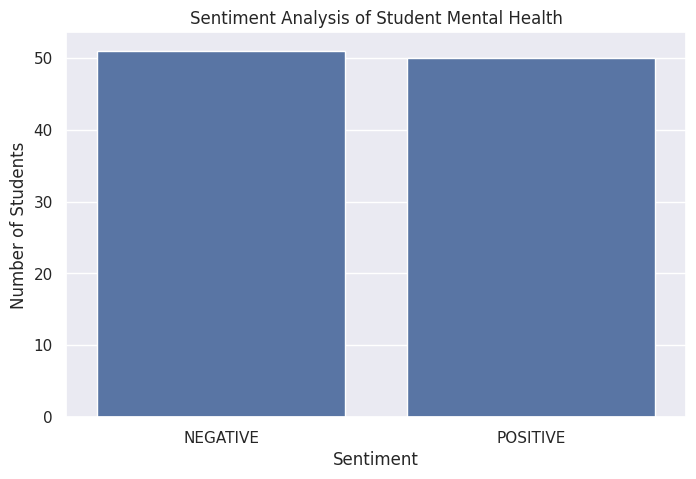

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(x="Sentiment", data=df)
plt.title("Sentiment Analysis of Student Mental Health")
plt.xlabel("Sentiment")
plt.ylabel("Number of Students")
plt.show()

### Compare sentiment with depression

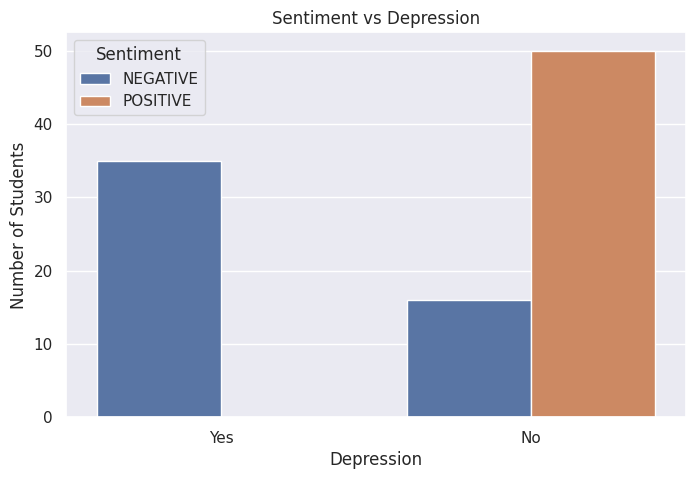

In [45]:
plt.figure(figsize=(8, 5))
sns.countplot(
    x="Do you have Depression?",
    hue="Sentiment",
    data=df
)
plt.title("Sentiment vs Depression")
plt.xlabel("Depression")
plt.ylabel("Number of Students")
plt.show()

### Optional: Save the results

Run the following cell if you want to download the analyzed dataset as a CSV file from Google Colab.


In [46]:
df.to_csv("student_mental_health_sentiment_results.csv", index=False)
print("Saved as student_mental_health_sentiment_results.csv")

Saved as student_mental_health_sentiment_results.csv
